In [41]:
from stress_risk.behavior.utils import get_data
import seaborn as sns
import pingouin
import numpy as np

In [42]:
df = get_data()

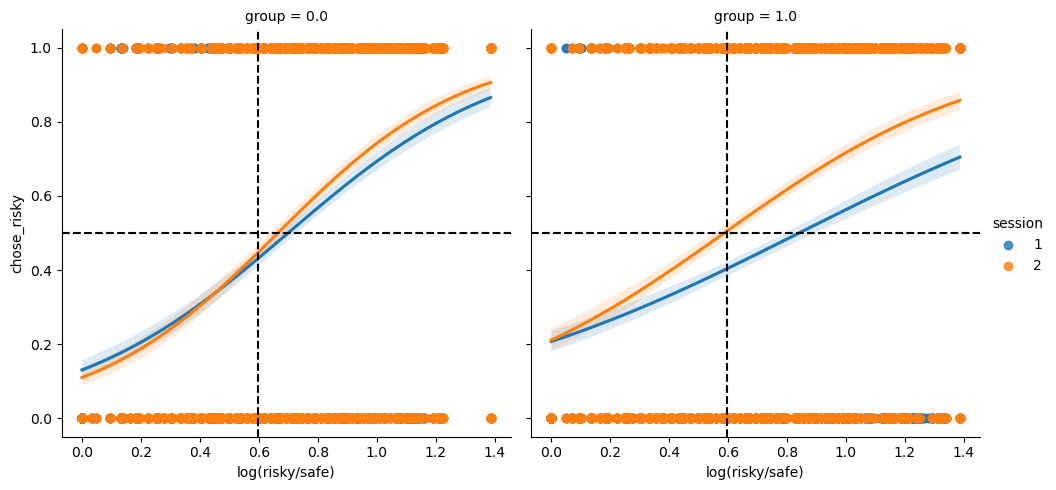

In [43]:
fac = sns.lmplot(x='log(risky/safe)', y='chose_risky', data=df.reset_index(), logistic=True, col='group',hue='session')

for ax in fac.axes.ravel():
    ax.axhline(.5, c='k', ls='--')
    ax.axvline(np.log(1/.55), c='k', ls='--')

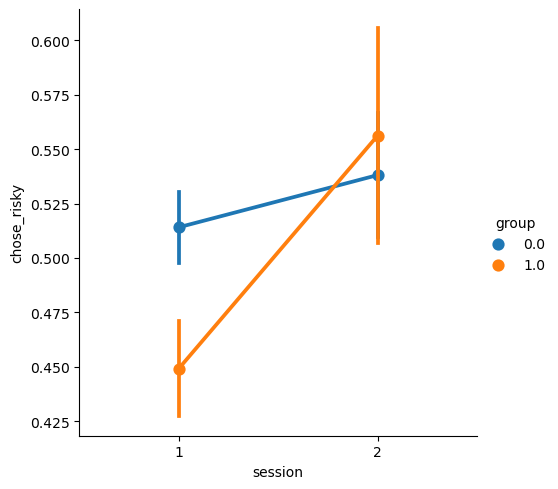

In [4]:
tmp = df.groupby(['subject', 'group', 'session']).mean()

fac = sns.catplot(y='chose_risky', data=tmp.reset_index(), x='session', hue='group', kind='point', errorbar='se')


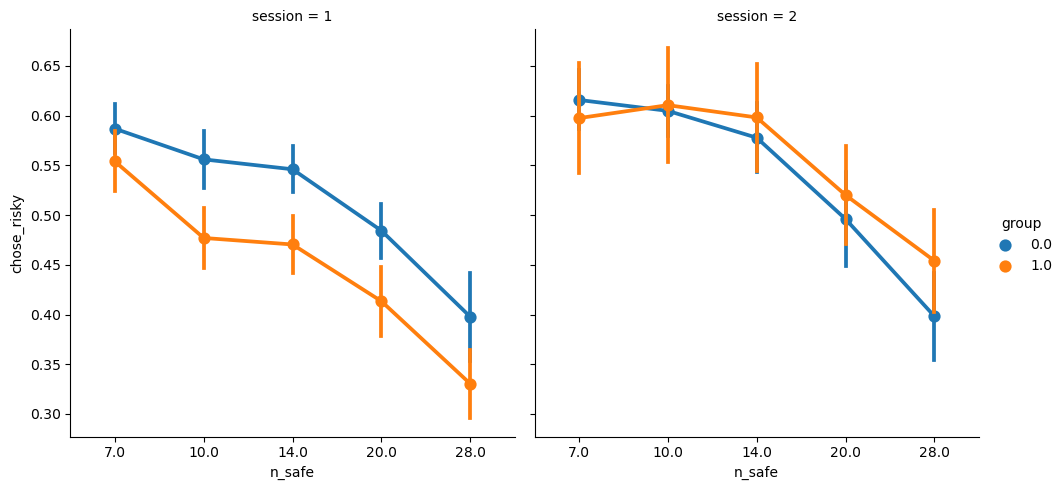

In [5]:
tmp = df.groupby(['subject', 'group', 'session', 'n_safe']).mean()

fac = sns.catplot(y='chose_risky', data=tmp.reset_index(), x='n_safe', hue='group', col='session', kind='point', errorbar='se')


In [6]:
pingouin.mixed_anova(tmp.reset_index(), dv='chose_risky', within='session',
between='group', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.014174,1,48,0.014174,0.450048,0.505528,0.009289,NaN
1,session,0.107834,1,48,0.107834,5.934859,0.018605,0.110038,1.0
2,Interaction,0.042739,1,48,0.042739,2.352207,0.131671,0.046715,NaN


In [7]:
import pandas as pd

In [38]:
#only first session
#rnp = pd.read_csv('/Users/mrenke/git/stress_risk/stress_risk/subject_selection/subjectwise_rnp.tsv', sep='\t', index_col='subject')
#both sessions
rnp = pd.read_csv('/Users/mrenke/git/stress_risk/stress_risk/behavior/subject-session-wise_rnp.tsv', sep='\t', index_col='subject')


In [22]:
tmp = df.groupby(['subject', 'group', 'session']).mean()
# combine both dataframes
com = pd.merge(tmp.reset_index(), rnp.reset_index(), how='left', on= ['subject', 'session', 'group'])

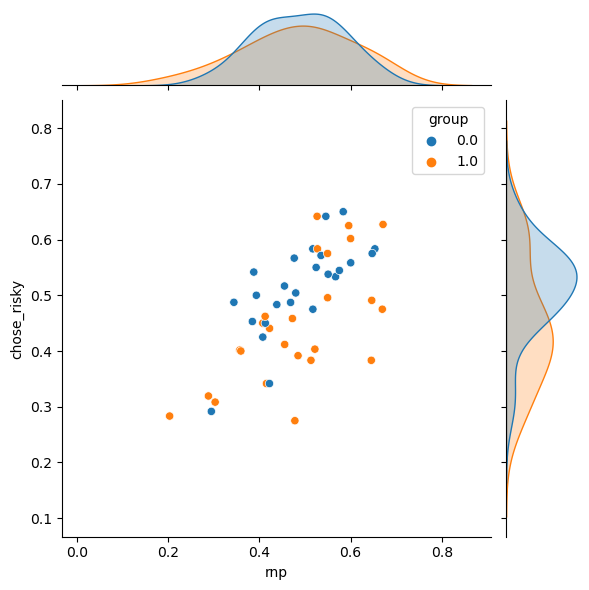

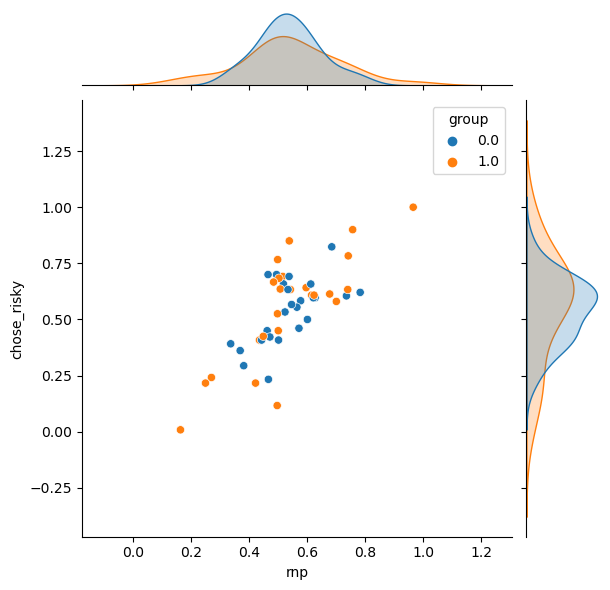

In [25]:
# plot 
sns.jointplot(com[com['session']==1].reset_index(), x='rnp', y='chose_risky', hue='group')
sns.jointplot(com[com['session']==2].reset_index(), x='rnp', y='chose_risky', hue='group')


In [31]:
pingouin.anova(com[com['session']==1], dv='chose_risky', between='group')

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,48,5.65574,0.021427,0.105408


In [37]:
pingouin.mixed_anova(com, dv='chose_risky', within='session',
between='group', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.013668,1,48,0.013668,0.434291,0.513040,0.008967,NaN
1,session,0.107293,1,48,0.107293,5.896973,0.018964,0.109412,1.0
2,Interaction,0.043121,1,48,0.043121,2.369970,0.130256,0.047051,NaN


In [36]:
pingouin.anova(com[com['session']==1].reset_index(), dv='rnp', between='group')

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,48,0.019228,0.890295,0.0004


In [35]:
pingouin.mixed_anova(com, dv='rnp', within='session',
between='group', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.000021,1,48,0.000021,0.000850,0.976862,0.000018,NaN
1,session,0.068894,1,48,0.068894,9.041586,0.004191,0.158509,1.0
2,Interaction,0.000284,1,48,0.000284,0.037271,0.847728,0.000776,NaN


In [19]:
#elif plot_type == 6:
groupby = ['risky_first', 'n_safe', 'session','group']
ppc = df.groupby(['subject']+groupby).mean()
e = ppc.mean(1).to_frame('p_predicted')

p = df.groupby(groupby)[['chose_risky']].mean()

ppc_s = e.join(p).reset_index()
ppc_s['Order'] = ppc_s['risky_first'].map({True:'Risky first', False:'Safe first'})
ppc_s['Safe offer'] = ppc_s['n_safe'].astype(int)

ppc_s['Prop. chosen risky'] = ppc_s['chose_risky']



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_38590/350049465.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ppc = df.groupby(['subject']+groupby).mean()


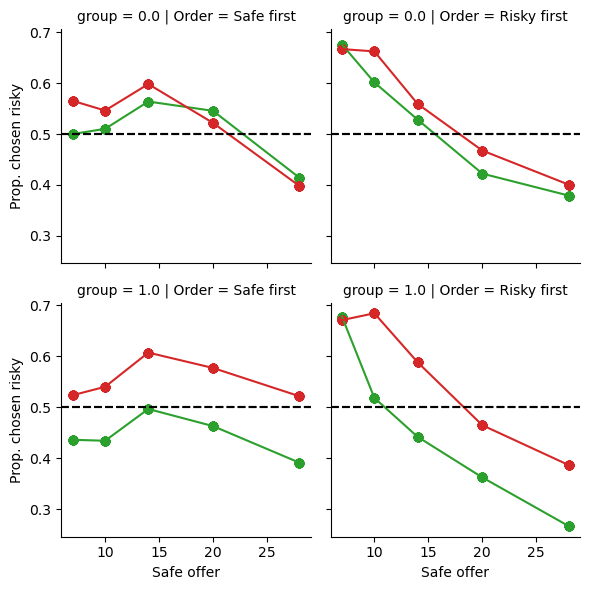

In [26]:
import matplotlib.pyplot as plt
x = 'Safe offer'

fac = sns.FacetGrid(ppc_s,
            col='Order',
            hue='session',
            row='group',
            palette=sns.color_palette()[2:])

fac.map(plt.plot, x, 'Prop. chosen risky', )
fac.map(plt.scatter, x, 'Prop. chosen risky')
fac.map(lambda *args, **kwargs: plt.axhline(.5, c='k', ls='--'))


In [12]:
df.to_csv('~/Desktop/complete_behavData.csv') #für Göki

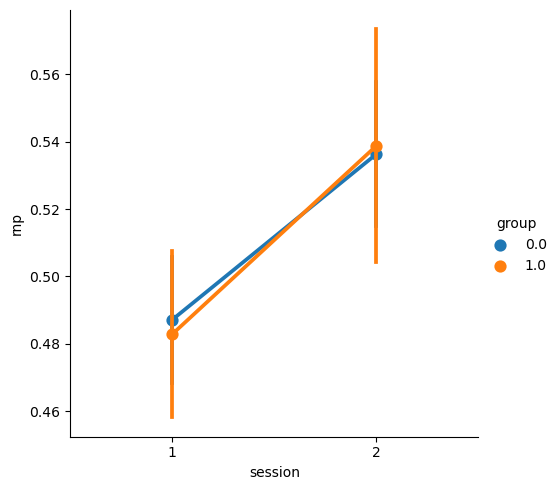

In [39]:
fac = sns.catplot(y='rnp', data=com, x='session', hue='group', kind='point', errorbar='se')
